# CIFAR-10 对比实验（ViT-Base vs D2NN-12，使用相同全连接头）

> 这个 Notebook 适用于云端 Jupyter / Colab / 其他 notebook 运行环境。  
> 目标：
> 1. 跑 **ViT-Base** 在 CIFAR-10 上的分类性能  
> 2. 跑 **D2NN 12层衍射 + 同一全连接头** 在 CIFAR-10 上的性能  
> 3. 给出可视化：样本展示、训练曲线、混淆矩阵、预测样例

## 0) 环境安装（如已安装可跳过）

> 云环境首次运行时建议先执行下面这一格。成功后会显示安装完成信息。

In [3]:
import subprocess
print(subprocess.check_output(
    ["nvidia-smi","--query-gpu=memory.total,memory.used,memory.free","--format=csv,noheader"],
    text=True
))

24576 MiB, 9850 MiB, 14274 MiB



## 1) 导入依赖 + 基础配置

- 这部分只做：导入包、设置随机种子、检查设备（GPU/CPU）。
- 如果你选了 CUDA 但云环境没 GPU，会自动回退到 CPU，并给出提示。

In [4]:
import os
import random
import math
import json
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import vit_b_16
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# -------------------------
# 基础配置（可按需修改）
# -------------------------
SEED = 42
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-4
NUM_WORKERS = 2
DATA_DIR = Path("./data")
OUT_DIR = Path("./results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PREFERRED_DEVICE = "cuda"  # 可改为 "cpu" 或 "cuda"


def set_seed(seed: int = 42):
    """设置随机种子，保证结果尽可能可复现。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def resolve_device(preferred: str = "cuda") -> torch.device:
    """选择训练设备：优先用用户指定设备，不可用则自动回退。"""
    if preferred.startswith("cuda") and not torch.cuda.is_available():
        print("⚠️ 检测到你请求 CUDA，但当前云环境无可用 GPU，自动回退到 CPU。")
        return torch.device("cpu")
    dev = torch.device(preferred)
    print(f"✅ 当前使用设备: {dev}")
    return dev


set_seed(SEED)
DEVICE = resolve_device(PREFERRED_DEVICE)
print("✅ 基础配置完成")

✅ 当前使用设备: cuda
✅ 基础配置完成


/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) 数据加载（CIFAR-10）+ 可视化检查

- 这里会下载/读取 CIFAR-10，并创建 train/test loader。
- 会展示一小批图片，确认数据和标签正常。

In [5]:
# 为了和 ViT 输入对齐，这里把 CIFAR-10 的 32x32 resize 到 224x224
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_ds = datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True, transform=train_tfms)
test_ds = datasets.CIFAR10(root=str(DATA_DIR), train=False, download=True, transform=test_tfms)
classes = train_ds.classes

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"✅ 数据加载完成: train={len(train_ds)}, test={len(test_ds)}")
print(f"✅ 类别: {classes}")

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


✅ 数据加载完成: train=50000, test=10000
✅ 类别: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipykernel_134919/3619643007.py:19: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_134919/3619643007.py:19: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_134919/3619643007.py:19: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_134919/3619643007.py:19: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_134919/3619643007.py:19: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_134919/3619643007.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_134919/3619643007.py:19: UserWarning: Glyph 35757 (\N{CJK UNIFIED I

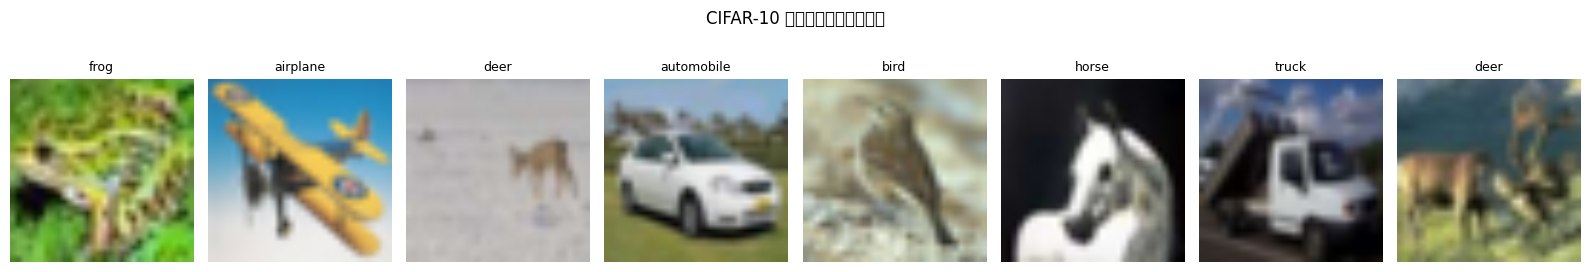

✅ 样本展示完成


In [6]:
# 展示一批样本（只在 CPU 做，不占 GPU）
def denorm(x):
    return x * 0.5 + 0.5

imgs, labels = next(iter(train_loader))
imgs = imgs.cpu()
labels = labels.cpu()

show_n = min(8, imgs.size(0))
plt.figure(figsize=(16, 3))
for i in range(show_n):
    ax = plt.subplot(1, show_n, i + 1)
    img = denorm(imgs[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(classes[int(labels[i])], fontsize=9)
    ax.axis("off")
plt.suptitle("CIFAR-10 样本可视化（训练集）", fontsize=12)
plt.tight_layout()
plt.show()
print("✅ 样本展示完成")


## 3) 模型定义（共享全连接头）

> 这里沿用仓库 D2NN 思路：复数场 + 可学习相位层 + 层间传播。  
> 对比公平性：两个模型都接入同一种全连接分类头（SharedFCHead）。

In [7]:
class SharedFCHead(nn.Module):
    """共享分类头：Linear -> ReLU -> Dropout -> Linear"""
    def __init__(self, in_dim: int, hidden_dim: int = 512, num_classes: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class ViTWithSharedHead(nn.Module):
    """ViT-Base 主干 + 共享全连接头"""
    def __init__(self, num_classes: int = 10, fc_hidden_dim: int = 512):
        super().__init__()
        self.backbone = vit_b_16(weights=None)
        in_dim = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Identity()  # 去掉原始分类头
        self.head = SharedFCHead(in_dim, hidden_dim=fc_hidden_dim, num_classes=num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)

# ===== D2NN 模型（替换你原来的 D2NN 类）=====
class DiffractiveLayer(nn.Module):
    def __init__(self, channels: int, height: int, width: int):
        super().__init__()
        # raw 参数映射到 [0, 2pi]
        self.phase_raw = nn.Parameter(torch.zeros(channels, height, width))

    def forward(self, field: torch.Tensor) -> torch.Tensor:
        phase = 2 * torch.pi * torch.sigmoid(self.phase_raw)
        return field * torch.exp(1j * phase)


class D2NN12WithSharedHead(nn.Module):
    def __init__(self, img_size: int = 224, channels: int = 3, num_classes: int = 10, fc_hidden_dim: int = 512):
        super().__init__()
        self.layers = nn.ModuleList([DiffractiveLayer(channels, img_size, img_size) for _ in range(12)])

        # ASM 传播核（贴近仓库逻辑）
        wl = 532e-9
        pixel_size = 8e-6
        distance = 0.01
        fx = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fxx, fyy = np.meshgrid(fx, fy)
        inside = (1.0 / wl) ** 2 - fxx ** 2 - fyy ** 2
        inside[inside < 0] = 0
        kz = 2 * np.pi * np.sqrt(inside)
        h = np.exp(1j * kz * distance).astype(np.complex64)
        self.register_buffer("transfer", torch.from_numpy(h))

        self.pool = nn.AdaptiveAvgPool2d((8, 8))
        self.fc_head = SharedFCHead(channels * 8 * 8, hidden_dim=fc_hidden_dim, num_classes=num_classes)

    def propagate(self, field: torch.Tensor) -> torch.Tensor:
        spec = torch.fft.fftshift(torch.fft.fft2(field), dim=(-2, -1))
        out_spec = spec * self.transfer
        return torch.fft.ifft2(torch.fft.ifftshift(out_spec, dim=(-2, -1)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        field = x.to(torch.complex64)
        for layer in self.layers:
            field = layer(field)
            field = self.propagate(field)
        intensity = torch.abs(field) ** 2
        pooled = self.pool(intensity).flatten(1)
        return self.fc_head(pooled)



print("✅ 模型定义完成")

✅ 模型定义完成


In [8]:
# ===== D2NN 两阶段参数冻结策略 =====
def select_phase_only_params(model: nn.Module):
    """
    第一阶段：训练 phase + fc_head
    （只训练 phase 在 CIFAR10 往往卡在接近随机水平）
    """
    for p in model.parameters():
        p.requires_grad = False
    params_to_update = []
    for name, p in model.named_parameters():
        if ("phase_raw" in name) or ("fc_head" in name):
            p.requires_grad = True
            params_to_update.append(p)
    return params_to_update


def unfreeze_all_params(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True
    return [p for p in model.parameters() if p.requires_grad]



## 4) 训练与评估工具（带进度条 + 训练日志）

- 每个 epoch 都有 tqdm 进度条
- 会记录训练损失、测试准确率，后面可画曲线

In [9]:
@dataclass
class RunMetrics:
    model: str
    epochs: int
    best_val_acc: float
    last_val_acc: float
    last_train_loss: float


def evaluate(model, loader, device):
    model.eval()
    total, correct = 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Eval", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            preds = logits.argmax(dim=1)

            total += y.size(0)
            correct += (preds == y).sum().item()
            preds_all.append(preds.cpu())
            labels_all.append(y.cpu())

    acc = correct / max(total, 1)
    preds_all = torch.cat(preds_all) if preds_all else torch.tensor([])
    labels_all = torch.cat(labels_all) if labels_all else torch.tensor([])
    return acc, preds_all, labels_all


def train_model(model, train_loader, test_loader, device, epochs=5, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "val_acc": []}
    best_acc = 0.0
    final_preds, final_labels = None, None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, total_samples = 0.0, 0

        pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}/{epochs}")
        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            running_loss += loss.item() * bs
            total_samples += bs
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / max(total_samples, 1)
        val_acc, preds, labels = evaluate(model, test_loader, device)

        history["train_loss"].append(epoch_loss)
        history["val_acc"].append(val_acc)

        if val_acc >= best_acc:
            best_acc = val_acc
            final_preds, final_labels = preds, labels

        print(f"✅ Epoch {epoch}: train_loss={epoch_loss:.4f}, val_acc={val_acc*100:.2f}%")

    metrics = RunMetrics(
        model=model.__class__.__name__,
        epochs=epochs,
        best_val_acc=best_acc,
        last_val_acc=history["val_acc"][-1],
        last_train_loss=history["train_loss"][-1],
    )
    return metrics, history, final_preds, final_labels


print("✅ 训练工具准备完成")

✅ 训练工具准备完成


In [10]:
# ===== D2NN 两阶段训练（替换你原来的 D2NN 训练函数）=====
def train_d2nn_two_stage(model: nn.Module, train_loader, val_loader, device,
                         phase_epochs: int = 12, finetune_epochs: int = 40,
                         phase_lr: float = 2e-3, finetune_lr: float = 3e-4):
    model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_acc, last_acc = 0.0, 0.0
    last_loss = math.nan

    print("\n[Stage-1] 训练 phase + fc_head")
    phase_params = select_phase_only_params(model)
    optimizer = torch.optim.AdamW(phase_params, lr=phase_lr, weight_decay=1e-4)
    scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(phase_epochs, 1))

    for epoch in range(phase_epochs):
        model.train()
        running, samples = 0.0, 0
        for x, y in tqdm(train_loader, desc=f"D2NN phase-only {epoch+1}/{phase_epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running += loss.item() * y.size(0)
            samples += y.size(0)

        scheduler1.step()
        last_loss = running / max(samples, 1)
        last_acc = evaluate(model, val_loader, device)[0]  # 这里 evaluate 返回 float，不用 [0]
        best_acc = max(best_acc, last_acc)
        print(f"[Stage-1][{epoch+1}] loss={last_loss:.4f}, val_acc={last_acc*100:.2f}%")


    
    print("\n[Stage-2] 解锁全参数联合微调")

    phase_params, head_params, dist_params = [], [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if "phase_raw" in n:
            phase_params.append(p)
        elif "fc_head" in n:
            head_params.append(p)
        elif "distance" in n or "transfer" in n or "kz" in n:
            dist_params.append(p)
        else:
            head_params.append(p)
    
    optimizer = torch.optim.AdamW([
        {"params": phase_params, "lr": 2e-4, "weight_decay": 1e-4},
        {"params": head_params,  "lr": 1e-4, "weight_decay": 1e-4},
        {"params": dist_params,  "lr": 5e-6, "weight_decay": 0.0},
    ])
    scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=finetune_epochs)

    
    # all_params = unfreeze_all_params(model)
    # optimizer = torch.optim.AdamW(all_params, lr=finetune_lr, weight_decay=1e-4)
    # scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(finetune_epochs, 1))

    

    for epoch in range(finetune_epochs):
        model.train()
        running, samples = 0.0, 0
        for x, y in tqdm(train_loader, desc=f"D2NN finetune {epoch+1}/{finetune_epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            running += loss.item() * y.size(0)
            samples += y.size(0)

        scheduler2.step()
        last_loss = running / max(samples, 1)
        last_acc = evaluate(model, val_loader, device)[0]
        best_acc = max(best_acc, last_acc)
        print(f"[Stage-2][{epoch+1}] loss={last_loss:.4f}, val_acc={last_acc*100:.2f}%")

    return {"best_val_acc": best_acc, "last_val_acc": last_acc, "last_train_loss": last_loss}

print("D2NN prepared")

D2NN prepared


## 5) 运行实验：ViT-Base + Shared FC

In [ ]:
vit_model = ViTWithSharedHead(num_classes=10, fc_hidden_dim=512)
vit_metrics, vit_hist, vit_preds, vit_labels = train_model(
    vit_model, train_loader, test_loader, DEVICE, epochs=EPOCHS, lr=LR
)
print("✅ ViT 实验结束")
print(vit_metrics)

Train Epoch 1/5: 100%|██████████| 782/782 [06:11<00:00,  2.11it/s, loss=1.4351]
                                                       

✅ Epoch 1: train_loss=1.7148, val_acc=40.02%


Train Epoch 2/5:   6%|▌         | 45/782 [00:21<05:49,  2.11it/s, loss=1.5897]

## 6) 运行实验：D2NN-12 + Shared FC

In [51]:
# ViT 那段保持你现有结果，不用重跑
# 只跑 D2NN：

d2nn_model = D2NN12WithSharedHead(img_size=224, channels=3, num_classes=10, fc_hidden_dim=512)

d2nn_result = train_d2nn_two_stage(
    d2nn_model,
    train_loader,
    test_loader,
    DEVICE,
    phase_epochs=5,      # 可先 2~8
    finetune_epochs=3,  # 可 5~10
    phase_lr=2e-3,
    finetune_lr=2e-4
)

print("D2NN result:", d2nn_result)

print("✅ D2NN 实验结束")
print(d2nn_metrics)


[Stage-1] 训练 phase + fc_head


D2NN phase-only 1/5: 100%|██████████| 782/782 [00:49<00:00, 15.96it/s]
                                                       

[Stage-1][1] loss=1.9440, val_acc=43.53%


D2NN phase-only 2/5: 100%|██████████| 782/782 [00:49<00:00, 15.94it/s]
                                                       

[Stage-1][2] loss=1.7249, val_acc=47.45%


...

[Stage-2][3] loss=1.5074, val_acc=53.64%


D2NN finetune 4/5: 100%|██████████| 782/782 [00:49<00:00, 15.89it/s]
                                                       

[Stage-2][4] loss=1.5035, val_acc=53.49%


D2NN finetune 5/5: 100%|██████████| 782/782 [00:49<00:00, 15.89it/s]
                                                       

[Stage-2][5] loss=1.4999, val_acc=53.61%
D2NN result: {'best_val_acc': 0.5364, 'last_val_acc': 0.5361, 'last_train_loss': 1.4999220933532715}
✅ D2NN 实验结束
RunMetrics(model='D2NN12WithSharedHead', epochs=5, best_val_acc=0.3139, last_val_acc=0.3139, last_train_loss=1.9865238352966308)


## 7) 对比结果保存（JSON）

In [11]:
summary = {
    "vit_base_shared_fc": asdict(vit_metrics),
    "d2nn_12_shared_fc": asdict(d2nn_metrics),
}

out_file = OUT_DIR / "cifar10_vit_vs_d2nn_notebook.json"
out_file.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print("✅ 对比结果已保存:", out_file)
print(json.dumps(summary, indent=2, ensure_ascii=False))

NameError: name 'vit_metrics' is not defined

## 8) 可视化：训练曲线（loss / acc）

In [1]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(vit_hist["train_loss"], marker="o", label="ViT train_loss")
plt.plot(d2nn_hist["train_loss"], marker="o", label="D2NN train_loss")
plt.title("训练损失曲线")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.array(vit_hist["val_acc"]) * 100, marker="o", label="ViT val_acc")
plt.plot(np.array(d2nn_hist["val_acc"]) * 100, marker="o", label="D2NN val_acc")
plt.title("验证准确率曲线")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
print("✅ 训练曲线绘制完成")

NameError: name 'plt' is not defined

## 9) 可视化：混淆矩阵

/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from

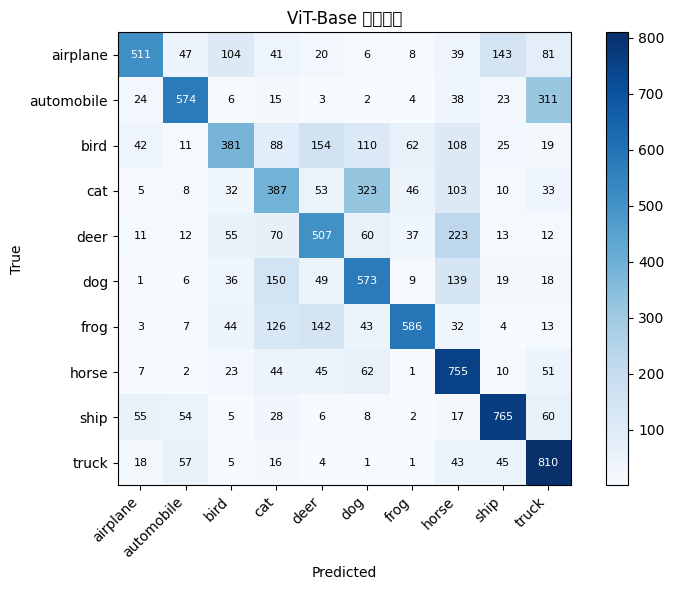

/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/2137589014.py:28: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from

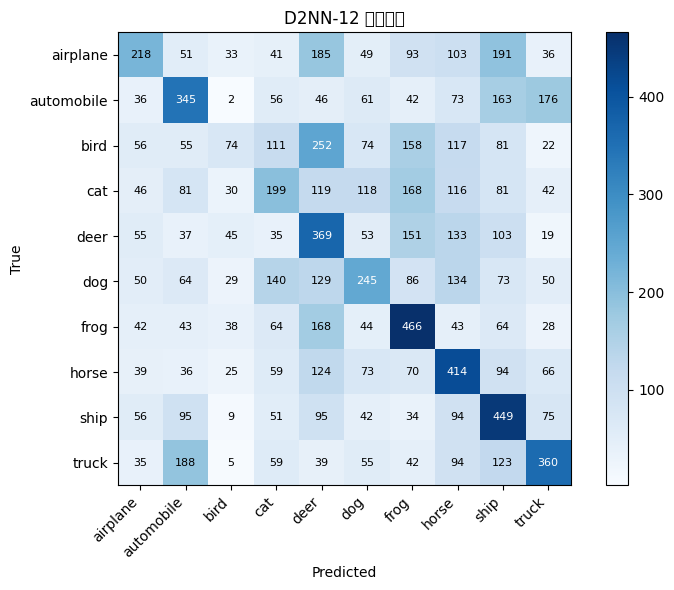

✅ 混淆矩阵绘制完成


In [49]:
def build_confusion_matrix(preds: torch.Tensor, labels: torch.Tensor, num_classes: int = 10):
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for p, t in zip(preds, labels):
        cm[t.long(), p.long()] += 1
    return cm


def plot_confusion_matrix(cm: torch.Tensor, class_names, title="Confusion Matrix"):
    cm_np = cm.numpy()
    plt.figure(figsize=(8, 6))
    plt.imshow(cm_np, cmap="Blues")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # 在格子中标注数值，方便判断哪些类容易混淆
    thresh = cm_np.max() / 2 if cm_np.size > 0 else 0
    for i in range(cm_np.shape[0]):
        for j in range(cm_np.shape[1]):
            plt.text(j, i, str(cm_np[i, j]),
                     ha="center", va="center",
                     color="white" if cm_np[i, j] > thresh else "black",
                     fontsize=8)
    plt.tight_layout()
    plt.show()


vit_cm = build_confusion_matrix(vit_preds, vit_labels, num_classes=len(classes))
d2nn_cm = build_confusion_matrix(d2nn_preds, d2nn_labels, num_classes=len(classes))

plot_confusion_matrix(vit_cm, classes, title="ViT-Base 混淆矩阵")
plot_confusion_matrix(d2nn_cm, classes, title="D2NN-12 混淆矩阵")
print("✅ 混淆矩阵绘制完成")

## 10) 可视化：随机预测样例展示

/tmp/ipykernel_79329/4259097904.py:28: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/4259097904.py:28: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/4259097904.py:28: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/4259097904.py:28: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/4259097904.py:28: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/4259097904.py:28: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79329/4259097904.py:28: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAP

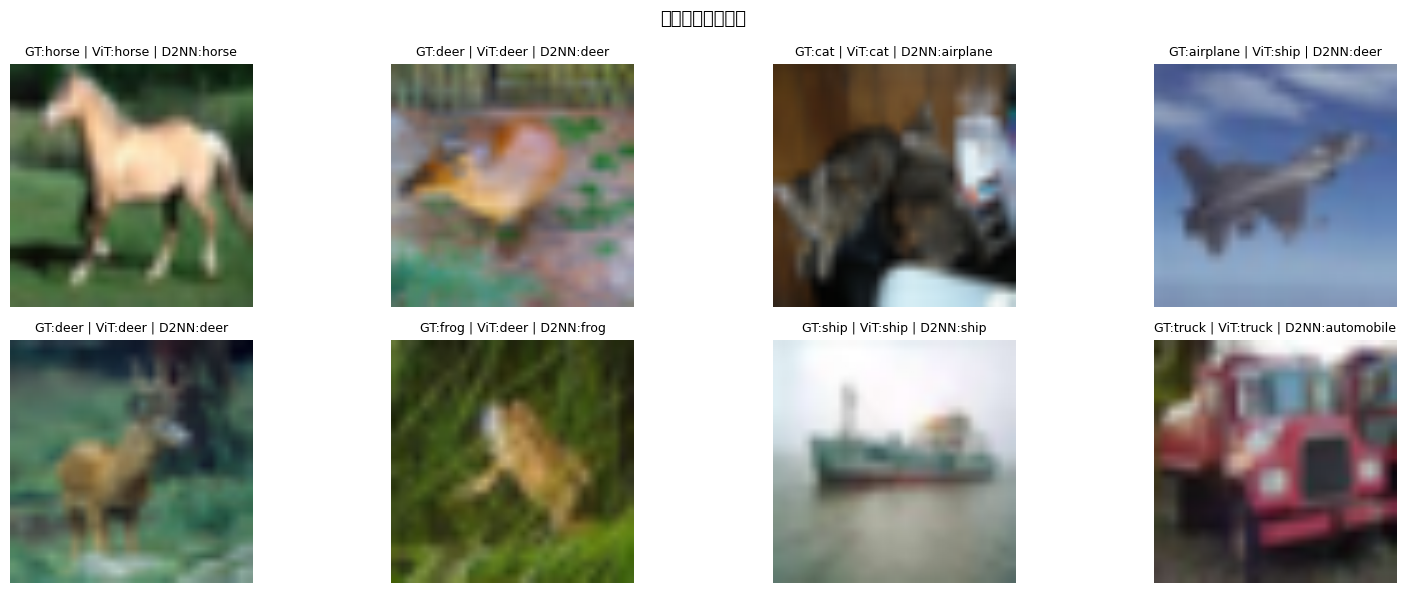

✅ 随机样例可视化完成


In [36]:
# 从测试集中随机抽一批，展示图像 + GT + 两模型预测
idxs = np.random.choice(len(test_ds), size=8, replace=False)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(16, 6))
for i, idx in enumerate(idxs):
    img, label = test_ds[idx]
    x = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        vit_pred = vit_model(x).argmax(dim=1).item()
        d2nn_pred = d2nn_model(x).argmax(dim=1).item()

    ax = plt.subplot(2, 4, i + 1)
    vis = (img * 0.5 + 0.5).permute(1, 2, 0).numpy()
    vis = np.clip(vis, 0, 1)
    ax.imshow(vis)
    ax.set_title(
        f"GT:{classes[label]} | ViT:{classes[vit_pred]} | D2NN:{classes[d2nn_pred]}",
        fontsize=9
    )
    ax.axis("off")


plt.suptitle("测试样例预测对比", fontsize=13)
plt.tight_layout()
plt.show()
print("✅ 随机样例可视化完成")

## 11) 云环境运行建议（重要）

- 如果显存不足：把 `BATCH_SIZE` 调小到 16 或 8。  
- 如果 CPU 太慢：先把 `EPOCHS` 设为 1~2 做流程验证。  
- 如果你使用 Colab，建议先切换 Runtime 到 GPU。  
- 如果网络慢导致下载失败，可重跑“数据加载”单元格。

> 到这里你就有了可直接下载、可模块调试、带中文注释和可视化的完整 notebook。